# Linear Regression Training Pipeline

This notebook implements an end-to-end Linear Regression training pipeline with:
- Data loading and exploration
- Preprocessing and scaling
- Train-test split
- Model training
- Hyperparameter tuning with Optuna
- Model evaluation and validation

## 1. Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optimization
import optuna
import joblib
import math
import warnings

# Settings
sns.set(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("✅ Libraries imported.")

✅ Libraries imported.


c:\Users\Charles\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and Explore Dataset

In [2]:
# Load Dataset
try:
    df = pd.read_csv("typhoon_impact_cleaned.csv")
    
    # Standardize column names
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('/', '_')
    
    print(f"✅ Data Loaded. Shape: {df.shape}")

    # Define Features and Targets
    input_features = [
        'max_sustained_wind_kph',
        'typhoon_type',
        'max_24hr_rainfall_mm',
        'total_storm_rainfall_mm',
        'min_pressure_hpa',
        'duration_in_par_hours'
    ]

    target_columns = [
        'families', 'person', 'brgy', 'dead', 'injured_ill', 
        'missing', 'cost', 'partially', 'totally'
    ]
    
except FileNotFoundError:
    print("❌ Error: 'typhoon_impact_cleaned.csv' not found. Please upload the file.")

✅ Data Loaded. Shape: (59, 30)


In [3]:
# Exploration of the dataset
print(f"Raw Data Loaded: {df.shape}")
print("-" * 50)

print("\n--- Dataset Information (Data Types) ---")
df.info()

print("\n--- Summary Statistics (Check for outliers in Raw Data) ---")
print(df.describe())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("-" * 50)
print("Preview of First 3 Rows:")
df.head(3)

Raw Data Loaded: (59, 30)
--------------------------------------------------

--- Dataset Information (Data Types) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   typhoon_name             59 non-null     object 
 1   year                     59 non-null     int64  
 2   region                   59 non-null     int64  
 3   province                 59 non-null     object 
 4   city_municipality        59 non-null     object 
 5   families                 59 non-null     int64  
 6   person                   59 non-null     int64  
 7   brgy                     59 non-null     int64  
 8   dead                     59 non-null     int64  
 9   injured_ill              59 non-null     int64  
 10  missing                  59 non-null     int64  
 11  totally                  59 non-null     int64  
 12  partially        

,typhoon_name,year,region,province,city_municipality,families,person,brgy,dead,injured_ill,...,par_end,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_station_mapped,weather_records_found,weather_days_covered
0,KARDING,2022,2,CAGAYAN,APARRI,278,1084,2,0,0,...,9/26/2022,114.0,195,4,25.0,57.0,1004.1,1,5,5
1,MAYMAY,2022,2,CAGAYAN,APARRI,5297,21011,29,0,0,...,10/12/2022,54.0,45,0,132.9,280.7,1005.9,1,3,3
2,OBET,2022,2,CAGAYAN,APARRI,2202,7516,13,0,0,...,10/22/2022,86.5,55,0,106.0,202.8,1001.6,1,4,4


## 4. Train-Test Split

In [ ]:
X = df[input_features]
indices = df.index 

X_train_raw, X_test_raw, idx_train, idx_test = train_test_split(
    X, indices, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("✅ Data Split and Scaled.")
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape:  {X_test.shape}")

✅ Data Split and Scaled.
Train Shape: (47, 6)
Test Shape:  (12, 6)


## 6. Basic Linear Regression Model Training

In [6]:
baseline_metrics = []
baseline_models = {}

print(f"{'TARGET':<15} | {'BASELINE R2':<15} | {'BASELINE RMSE':<15}")
print("-" * 50)

for target in target_columns:
    # Get Target Data
    y_train = df.loc[idx_train, target]
    y_test_actual = df.loc[idx_test, target]

    # Initialize and Train Simple Linear Regression (No Tuning)
    model = LinearRegression()
    model.fit(X_train, y_train)
    baseline_models[target] = model
    
    # Predict
    y_pred = np.maximum(model.predict(X_test), 0) # Enforce non-negative
    
    # Calculate Baseline Metrics
    r2 = r2_score(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    
    baseline_metrics.append({
        'Target': target,
        'Type': 'Baseline',
        'R2': r2,
        'RMSE': rmse
    })
    
    print(f"{target:<15} | {r2:.4f}          | {rmse:,.1f}")

print("\n✅ Baseline Training Complete.")

TARGET          | BASELINE R2     | BASELINE RMSE  
--------------------------------------------------
families        | -0.2391          | 1,296.5
person          | -1.4682          | 4,679.5
brgy            | -2.2822          | 9.8
dead            | 1.0000          | 0.0
injured_ill     | 0.0000          | 0.6
missing         | 1.0000          | 0.0
cost            | -0.3086          | 892,861.8
partially       | -0.2878          | 71.1
totally         | -4.8252          | 7.3

✅ Baseline Training Complete.


## 7. Hyperparameter Tuning with Optuna

In [7]:
best_params_dict = {}

print("Starting Optuna Tuning...")
print(f"{'TARGET':<15} | {'BEST ALPHA':<15} | {'BEST CV SCORE (Neg MSE)':<25}")
print("-" * 60)

for target in target_columns:
    y_train = df.loc[idx_train, target]
    
    # Define Objective Function
    def objective(trial):
        # Suggest alpha (regularization strength)
        alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
        
        model = Ridge(alpha=alpha)
        
        # Cross Validation (3-fold)
        # We use neg_mean_squared_error because Optuna maximizes the objective
        score = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_squared_error')
        return score.mean()

    # Create Study
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)
    
    best_params_dict[target] = study.best_params['alpha']
    print(f"{target:<15} | {study.best_params['alpha']:<15.4f} | {study.best_value:<25.4f}")

print("\n✅ Hyperparameter Tuning Complete.")

Starting Optuna Tuning...
TARGET          | BEST ALPHA      | BEST CV SCORE (Neg MSE)  
------------------------------------------------------------
families        | 98.1125         | -1911941.2162            
person          | 99.1563         | -35789503.3180           
brgy            | 97.4736         | -269.7722                
dead            | 0.8669          | 0.0000                   
injured_ill     | 99.7730         | -0.3260                  
missing         | 0.1187          | 0.0000                   
cost            | 18.3842         | -566331314747.1709       
partially       | 0.1318          | -3678.4350               
totally         | 14.7313         | -56.8065                 

✅ Hyperparameter Tuning Complete.


In [8]:
tuned_metrics = []
final_models = {}

# --- FIX: Safe creation of results dataframe ---
# We check if metadata columns exist in your dataframe before trying to use them
metadata_cols = ['typhoon_name', 'province'] 
existing_metadata = [col for col in metadata_cols if col in df.columns]

# Initialize the results dataframe with metadata (if found) or just empty with correct index
final_results_df = df.loc[idx_test, existing_metadata].copy().reset_index(drop=True)
# -----------------------------------------------

print(f"{'TARGET':<15} | {'TUNED R2':<15} | {'TUNED RMSE':<15} | {'IMPROVEMENT (R2)':<20}")
print("-" * 75)

for target in target_columns:
    # 1. Retrieve best alpha found by Optuna
    best_alpha = best_params_dict.get(target, 1.0) 
    
    # 2. Train Final Model (Ridge) on the full training set
    model = Ridge(alpha=best_alpha)
    y_train = df.loc[idx_train, target]
    model.fit(X_train, y_train)
    final_models[target] = model
    
    # 3. Predict on Test Set
    y_test_actual = df.loc[idx_test, target]
    y_pred = np.maximum(model.predict(X_test), 0) # Ensure no negative predictions
    
    # 4. Store predictions in the results dataframe
    final_results_df[f'{target}_Actual'] = y_test_actual.values
    final_results_df[f'{target}_Predicted'] = y_pred
    
    # 5. Calculate Metrics
    r2 = r2_score(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    
    tuned_metrics.append({
        'Target': target,
        'Type': 'Tuned',
        'R2': r2,
        'RMSE': rmse
    })
    
    # 6. Compare with Baseline (if baseline exists)
    try:
        baseline_r2 = next(item['R2'] for item in baseline_metrics if item['Target'] == target)
        improvement = r2 - baseline_r2
        imp_str = f"{improvement:+.4f}"
    except (NameError, StopIteration):
        imp_str = "N/A"
    
    print(f"{target:<15} | {r2:.4f}          | {rmse:,.1f}        | {imp_str}")

print("\n✅ Final Models Trained and Evaluated.")

TARGET          | TUNED R2        | TUNED RMSE      | IMPROVEMENT (R2)    
---------------------------------------------------------------------------
families        | -0.0361          | 1,185.5        | +0.2029
person          | -0.4273          | 3,558.5        | +1.0409
brgy            | -0.9024          | 7.4        | +1.3798
dead            | 1.0000          | 0.0        | +0.0000
injured_ill     | 0.0000          | 0.3        | +0.0000
missing         | 1.0000          | 0.0        | +0.0000
cost            | -0.0982          | 817,923.0        | +0.2104
partially       | -0.2673          | 70.5        | +0.0205
totally         | -2.1067          | 5.3        | +2.7185

✅ Final Models Trained and Evaluated.


## 8. Model Evaluation and Validation

In [9]:
# Initialize a list to store performance data
performance_data = []

print(f"{'TARGET':<15} | {'R2 SCORE':<10} | {'MAE':<15} | {'RMSE':<15}")
print("-" * 75)

for target in target_columns:
    y_true = final_results_df[f'{target}_Actual']
    y_pred = final_results_df[f'{target}_Predicted']
    
    # Calculate Metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    performance_data.append({
        'Target': target,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    })
    
    print(f"{target:<15} | {r2:.4f}     | {mae:,.2f}        | {rmse:,.2f}")

print("-" * 75)

TARGET          | R2 SCORE   | MAE             | RMSE           
---------------------------------------------------------------------------
families        | -0.0361     | 987.71        | 1,185.54
person          | -0.4273     | 3,133.00        | 3,558.52
brgy            | -0.9024     | 6.86        | 7.44
dead            | 1.0000     | 0.00        | 0.00
injured_ill     | 0.0000     | 0.22        | 0.30
missing         | 1.0000     | 0.00        | 0.00
cost            | -0.0982     | 588,607.74        | 817,923.00
partially       | -0.2673     | 43.92        | 70.54
totally         | -2.1067     | 3.50        | 5.34
---------------------------------------------------------------------------


## 10. Model Output and Summary

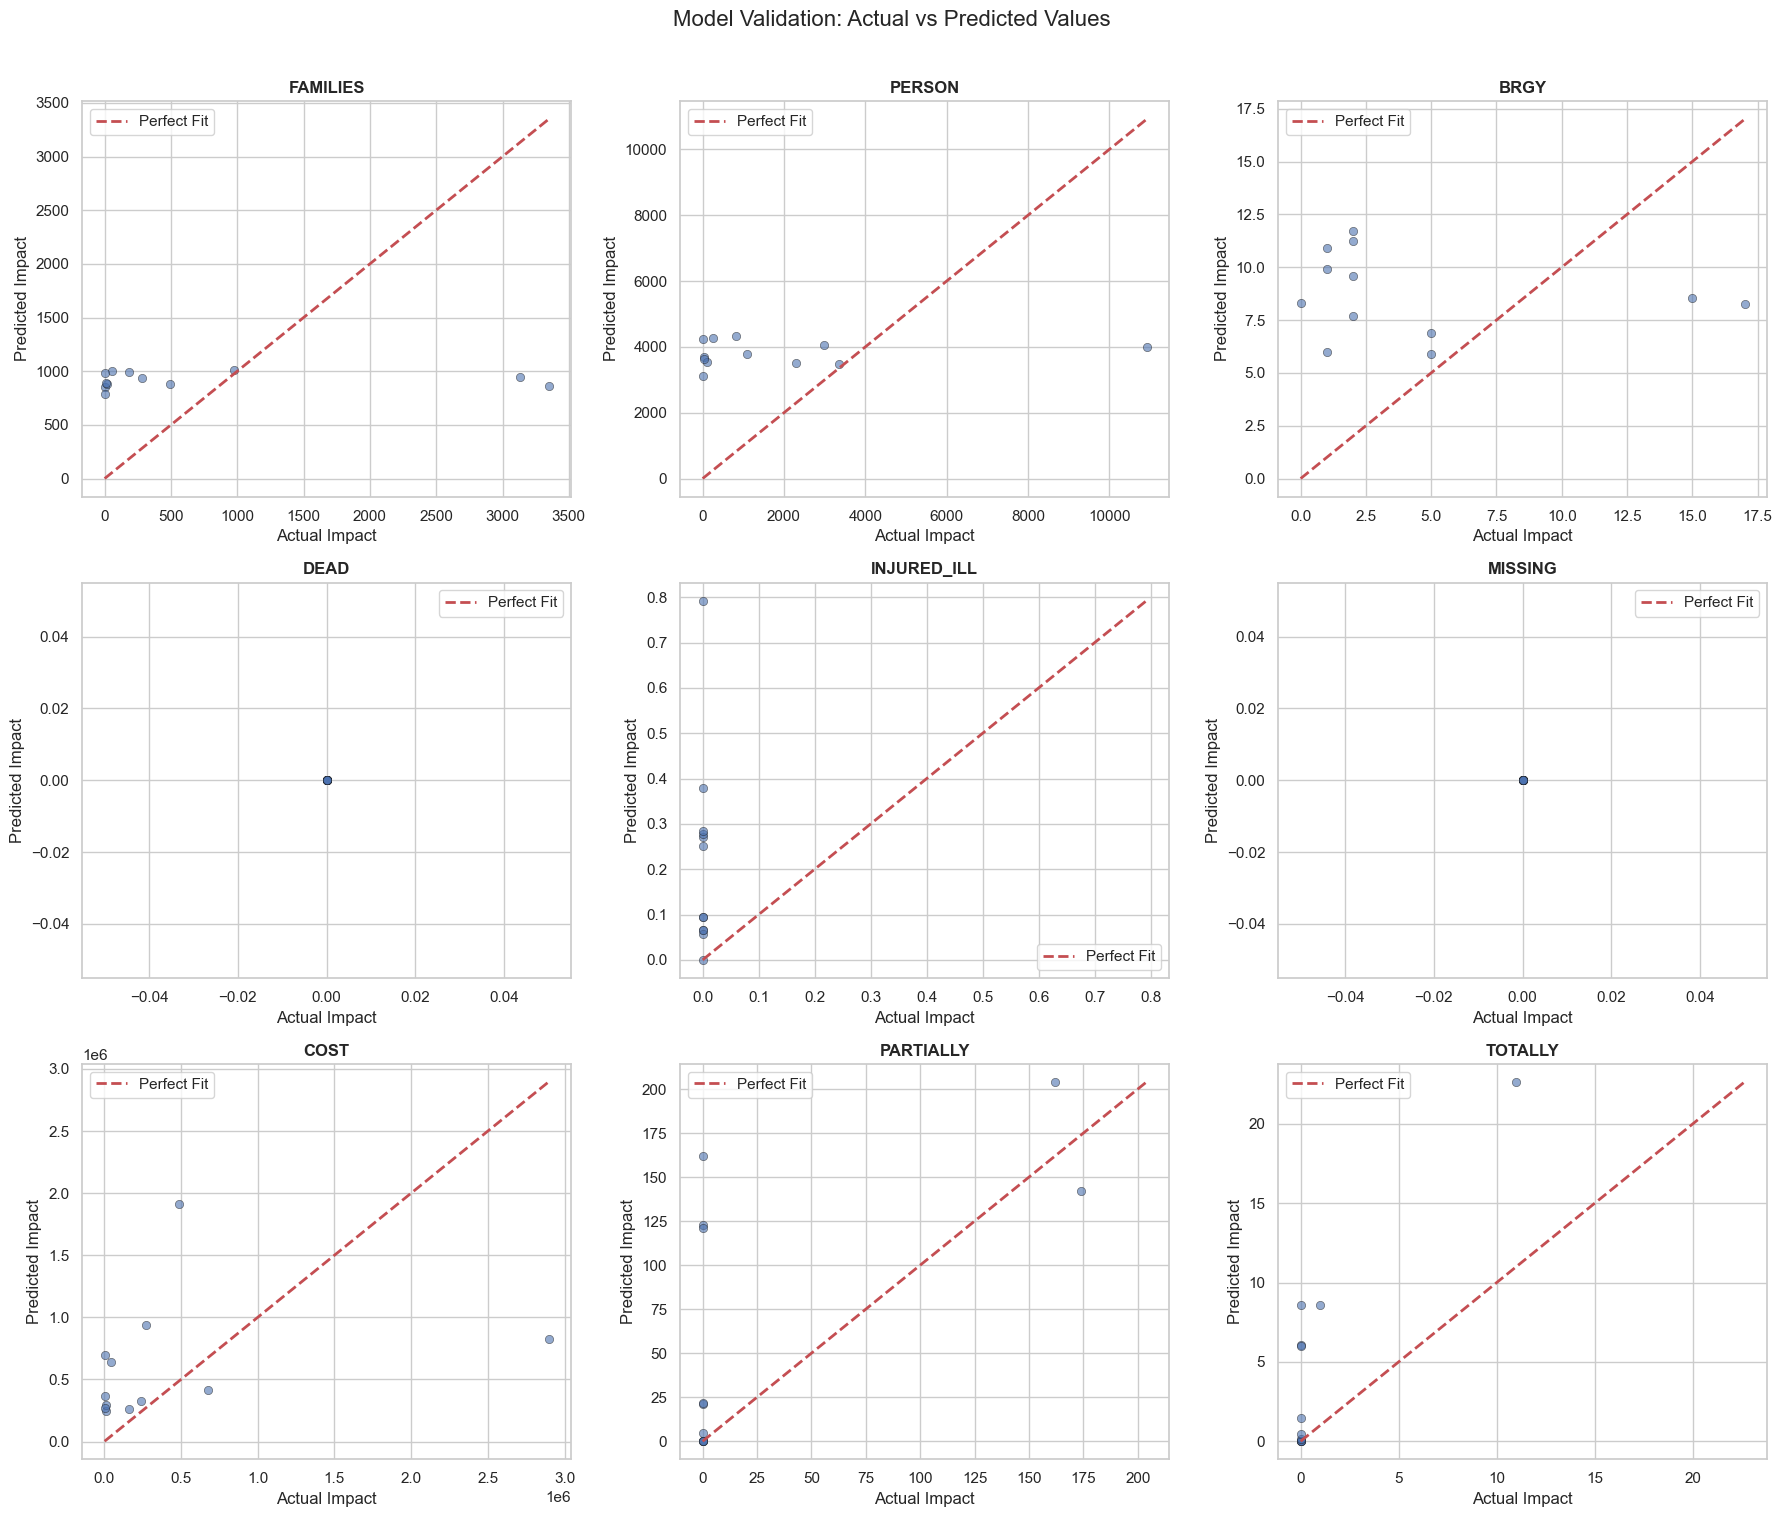

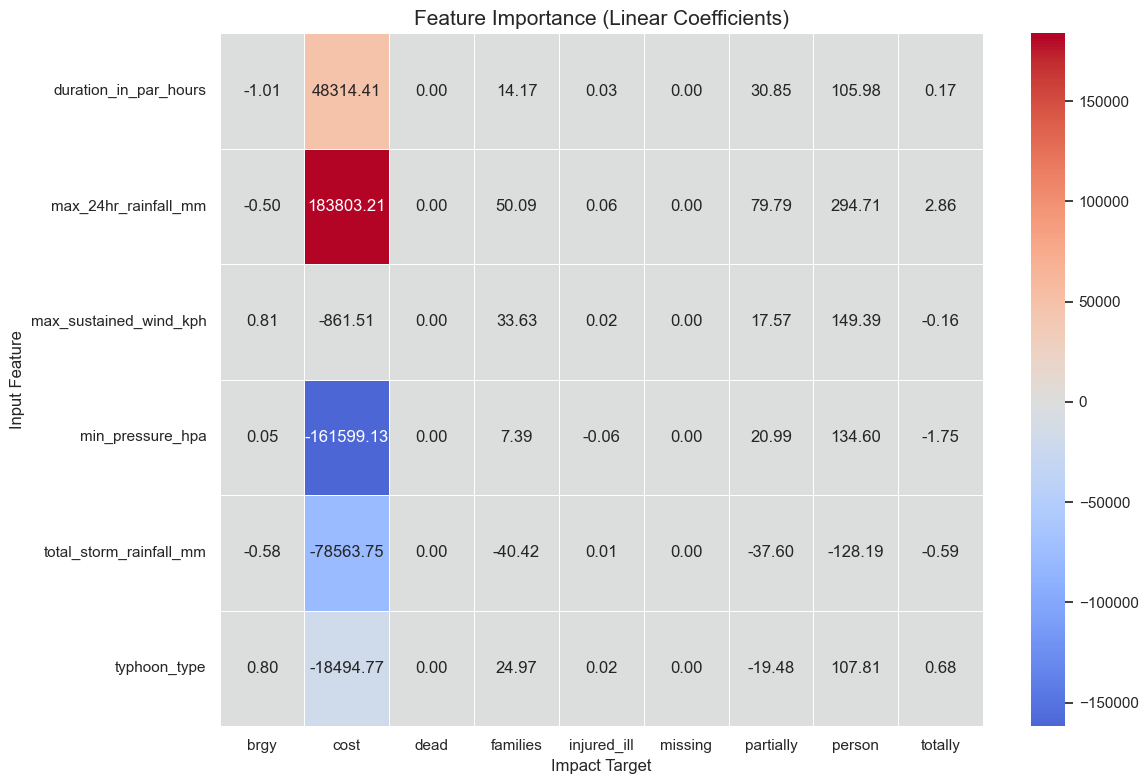

✅ Visualizations generated and saved.


In [ ]:
# --- PART 1: Actual vs Predicted Scatter Plots ---
cols = 3
rows = math.ceil(len(target_columns) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, target in enumerate(target_columns):
    ax = axes[i]
    y_true = final_results_df[f'{target}_Actual']
    y_pred = final_results_df[f'{target}_Predicted']
    
    # Scatter plot
    sns.scatterplot(x=y_true, y=y_pred, ax=ax, alpha=0.6, edgecolor='k')
    
    # Perfect fit line (y=x)
    max_val = max(y_true.max(), y_pred.max())
    min_val = min(y_true.min(), y_pred.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
    
    ax.set_title(f'{target.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Impact')
    ax.set_ylabel('Predicted Impact')
    ax.legend()

# Hide empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Model Validation: Actual vs Predicted Values', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


# --- PART 2: Feature Importance (Coefficients) ---
# Extract coefficients from the trained Ridge models
coef_data = []
for target in target_columns:
    model = final_models[target]
    for feature, coef in zip(input_features, model.coef_):
        coef_data.append({'Target': target, 'Feature': feature, 'Coefficient': coef})

coef_df = pd.DataFrame(coef_data)

# Plot Heatmap of Coefficients
plt.figure(figsize=(12, 8))
heatmap_data = coef_df.pivot(index='Feature', columns='Target', values='Coefficient')
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=.5)

plt.title('Feature Importance (Linear Coefficients)', fontsize=15)
plt.xlabel('Impact Target')
plt.ylabel('Input Feature')
plt.tight_layout()
plt.show()

print("✅ Visualizations generated and saved.")

In [11]:
results_filename = 'final_predictions_lr.csv'
final_results_df.to_csv(results_filename, index=False)
print(f"✅ Prediction results saved to: {results_filename}")

# pipeline_artifacts = {
#     'models': final_models,         # Dictionary of trained Ridge models
#     'scaler': scaler,               # The fitted Standard Scaler
#     'input_features': input_features,
#     'target_columns': target_columns,
#     'performance_metrics': performance_data
# }

# model_filename = 'tuned_ridge_pipeline.joblib'
# joblib.dump(pipeline_artifacts, model_filename)

# print(f"✅ Model pipeline saved to: {model_filename}")
# print("   (Contains: Models, Scaler, Feature Names, and Metrics)")

✅ Prediction results saved to: final_predictions_lr.csv
